# Wheat Grain-Yield Prediction from Secondary Traits (Heat-Stressed Wheat, 2015–16 season)

**Paper:** Improving Wheat Yield Prediction Using Secondary Traits and High-Density Phenotyping Under Heat-Stressed Environments.
*Frontiers in Plant Science* 12:633651, doi:[10.3389/fpls.2021.633651](https://doi.org/10.3389/fpls.2021.633651) ([PMC8502926](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8502926/)), published 2021-09-27.

**Author code:** R pipeline on Zenodo record [5512861](https://zenodo.org/records/5512861) (MIT license): `BLUE_allYears.R` and `Multivar_yieldpred_alltrait_allYear.R`.

**Data:** Dryad doi:[10.5061/dryad.vdncjsxrz](https://doi.org/10.5061/dryad.vdncjsxrz) (CC0), version with five season CSVs; this notebook uses **2016_Data.csv** (the 2015–16 season).

**Scope — partial demonstration (one season):**
1. Genotype **BLUEs** per trial with the authors' mixed model `lmer(trait ~ 0 + entry + (1|rep) + (1|rep:range))` (lme4).
2. **All-trait multivariate grain-yield prediction** (canopy temperature + NDVI time points + agronomic traits): stepwise regression, LASSO, ridge, ElasticNet.
3. **Leave-one-trial-out cross-validation** over the 10 trials (60 entries each); accuracy = mean over trials of `cor(predicted, observed BLUE)`.
4. Comparison with the paper's **Table 2** (2015–16 column: All-Traits r = 0.58 for all four models).

**Execution status:** this notebook was executed end-to-end on a fresh Google Colab **CPU** runtime (see final report for the validation date and session log).

> **AI-assisted adaptation notice / AI支援に関する注記:** The authors provided their analysis as R scripts (Zenodo 5512861), not as a Colab notebook. This notebook copies the authors' 2016-season R code with minimal, documented edits (no `setwd`, no plotting-library calls, `write.csv` enabled) and runs it with `Rscript`; **Python is only the launcher.** The full multi-season pipeline, heritability, univariate models, and selection analysis are not included. The executed example was validated; untested behavior is not guaranteed.
> **日本語:** 本ノートブックは著者のRスクリプト(Zenodo 5512861)の2016年分セクションを最小限の編集でコピーし、`Rscript`で実行します。Pythonは起動用のみです。全季節・遺伝率・単変量解析等は含みません。実行済みの例は検証済みですが、未テストの動作は保証されません。


## Runtime selection / ランタイム選択

- **Use a CPU runtime** (Runtime → Change runtime type → CPU). The authors' method is classical mixed-model and linear regression; there is no GPU code path, so a T4/GPU is unnecessary.
- **Expected duration:** dependency install ≈ 3–8 min, BLUEs ≈ 1–2 min, shrinkage-model cross-validation ≈ 5–15 min. Downloads < 1 MiB.
- Run all cells top to bottom (Runtime → Run all).

**日本語:** CPU ランタイムを使用してください（GPU不要）。全体の所要時間は目安 10–25 分、ダウンロードは 1 MiB 未満です。上から順に実行してください。


### Environment: R and author-required packages

The authors' 2016 pipeline uses `lme4` (BLUEs) and `caret` + `elasticnet` (LASSO/ridge/ElasticNet). Colab's image includes R; the packages are installed from Ubuntu's prebuilt `r-cran-*` packages (fast, no compilation), with a CRAN fallback. Versions are printed from the actual runtime.

**日本語:** R本体はColabに同梱、必要パッケージ(lme4, caret, elasticnet)をaptで導入し、失敗時はCRANからインストールします。


In [ ]:
import subprocess, sys, os, shutil

RSCRIPT = "/usr/bin/Rscript"
assert os.path.exists(RSCRIPT), "Rscript not found; install R (apt-get install r-base-core)"

print(subprocess.run([RSCRIPT, "-e", "cat(R.version.string)"], capture_output=True, text=True).stdout)

pkgs = ["lme4", "caret", "elasticnet", "Matrix", "MASS"]
have = subprocess.run([RSCRIPT, "-e", "cat(paste(rownames(installed.packages()), collapse='\n'))"],
                      capture_output=True, text=True).stdout.split()
missing = [p for p in pkgs if p not in have]
print("already installed:", [p for p in pkgs if p in have])
print("missing:", missing)

if missing:
    apt_pkgs = " ".join("r-cran-" + p.lower() for p in missing)
    r = subprocess.run(["bash", "-c", f"apt-get update -qq && DEBIAN_FRONTEND=noninteractive apt-get install -y --no-install-recommends {apt_pkgs}"],
                       timeout=900)
    if r.returncode != 0:
        print("apt install failed; falling back to CRAN install (slower)")
        repos = "install.packages(c(%s), repos='https://cloud.r-project.org')" % ",".join(f"'{p}'" for p in missing)
        subprocess.run([RSCRIPT, "-e", repos], check=True, timeout=2400)

ver = subprocess.run([RSCRIPT, "-e",
    "for (p in c('lme4','caret','elasticnet')) cat(p, as.character(packageVersion(p)), '\n')"],
    capture_output=True, text=True)
print(ver.stdout)
if ver.returncode != 0:
    print(ver.stderr[-2000:])
    raise RuntimeError("Required R packages are unavailable")
os.chdir("/content")


R version 4.6.1 (2026-06-24)


already installed: ['Matrix', 'MASS']
missing: ['lme4', 'caret', 'elasticnet']


lme4 2.0.6 
caret 7.0.1 
elasticnet 1.3 



### Minimal input: Dryad 2015–16 season CSV

Downloaded **inside Colab** from Dryad (dataset doi:10.5061/dryad.vdncjsxrz, version 140447). Dryad's **per-file API download now returns 401 for token-less clients** (verified in a diagnostic probe: `{"error":"Unauthorized, must have current bearer token"}`), while the **public whole-version archive** (`/api/v2/versions/140447/download`, 1,184,563 bytes) is served openly. This notebook therefore downloads the version zip (≈1.2 MiB — the entire dataset; only the two needed files are extracted), verifies the zip signature and members, and checks the extracted files against Dryad's published sizes and SHA-256 digests: `2016_Data.csv` = 166,985 bytes (file 1020255), `README.txt` = 4,094 bytes (file 1020259). **日本語:** Dryadのファイル単位APIはトークンが必要なため、公開されているバージョンZIP(約1.2MiB)を取得し、必要な2ファイルのみ展開してサイズとSHA-256を検証します。


In [ ]:
import subprocess, hashlib, zipfile, os

# Per-file SHA-256 digests published by Dryad API /api/v2/files/{id}
EXPECTED = {
    "2016_Data.csv": (166985, "53b505024f306e637f6670131d08710e4698cbab39c989b10e437e76181511bd"),
    "README.txt":    (4094,   "90896c0da67e6bc69f84b22b3ca9508cf55bf7404a9fe99ab0c0c46306677455"),
}
UA = "Mozilla/5.0 (X11; Linux x86_64) phenopaper-colab/1.0"
ZIP = "/content/dryad_vdncjsxrz_v140447.zip"

data = subprocess.run(["curl", "-sL", "--fail", "--max-time", "300", "-A", UA,
                       "https://datadryad.org/api/v2/versions/140447/download"],
                      capture_output=True).stdout
assert data[:4] == b"PK\x03\x04", f"not a zip (first bytes: {data[:16]!r})"
with open(ZIP, "wb") as f:
    f.write(data)
print(f"version zip: {len(data)} bytes from datadryad.org/api/v2/versions/140447/download")

with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()
    print("members:", names)
    for name, (nbytes, digest) in EXPECTED.items():
        member = next(n for n in names if n.endswith(name))
        blob = z.read(member)
        assert len(blob) == nbytes, f"{name}: expected {nbytes} bytes, got {len(blob)}"
        got = hashlib.sha256(blob).hexdigest()
        assert got == digest, f"{name}: sha256 mismatch ({got})"
        with open("/content/" + name, "wb") as f:
            f.write(blob)
        print(f"{name}: {len(blob)} bytes, sha256 verified ({got[:16]}...)")


version zip: 1184563 bytes from datadryad.org/api/v2/versions/140447/download
members: ['2016_Data.csv', '2018_Data.csv', '2017_Data.csv', '2019_Data.csv', 'README.txt', '2020_Data.csv']
2016_Data.csv: 166985 bytes, sha256 verified (53b505024f306e63...)
README.txt: 4094 bytes, sha256 verified (90896c0da67e6bc6...)


### Input preview

The 2015–16 season file has plot-level records for 10 alpha-lattice trials of 60 entries: canopy temperature (CT) and NDVI measured on 8 and 9 dates, agronomic traits (days to heading/maturity, plant height, spikes, spikelets, grains per spike, thousand grain weight) and grain yield (GRYLD, t/ha). Column names below are the actual CSV header. **日本語:** CSVの実データ構造（10試験×60系統、CT/NDVIの測定日、農業形質）を確認します。


In [ ]:
import pandas as pd

df = pd.read_csv("/content/2016_Data.csv")
print("shape:", df.shape)
print("columns:", list(df.columns))
print("trials:", sorted(df["trial"].unique()), " entries per trial:", df.groupby("trial").size().unique())
print(df[["trial", "entry", "GRYLD"]].head())
print(df[["CT_20160123", "NDVI_20160121", "DTHD", "GRYLD"]].describe().loc[["mean", "std"]])


shape: (1200, 32)
columns: ['plot_id', 'trial', 'rep', 'range', 'column', 'entry', 'CT_20160123', 'CT_20160204', 'CT_20160212', 'CT_20160223', 'CT_20160228', 'CT_20160302', 'CT_20160309', 'CT_20160315', 'NDVI_20160121', 'NDVI_20160130', 'NDVI_20160203', 'NDVI_20160207', 'NDVI_20160223', 'NDVI_20160228', 'NDVI_20160303', 'NDVI_20160310', 'NDVI_20160315', 'DTHD', 'DAYSMT', 'PH', 'SN', 'SPKLNG', 'SPLN', 'GRNSPK', 'TGW', 'GRYLD']
trials: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]  entries per trial: [120]
   trial  entry  GRYLD
0      1   1001   2.50
1      1   1002   3.04
2      1   1003   2.63
3      1   1004   2.39
4      1   1005   3.47
      CT_20160123  NDVI_20160121       DTHD     GRYLD
mean    18.013750       0.731842  70.146667  2.413283
std      2.113427       0.063032   3.045689  0.621774


### Step 1 — Genotype BLUEs per trial (authors' `BLUE_allYears.R`, 2016 section)

For each trial, the authors fit, for every trait column, `lmer(trait ~ 0 + entry + (1|rep) + (1|rep:range))` and take the genotype fixed effects as BLUEs (paper: *Materials and Methods, Statistical Analysis*, eq. 1). Edits vs. the author source: removed `rm(list=ls())`/`setwd`/plotting-library calls; `write.csv` enabled; a dimension/column assertion added. **日本語:** 著者の混合モデルで試験ごとにBLUEを推定します（編集箇所は作業ディレクトリ・作図ライブラリのみ）。


In [ ]:
BLUE_R = r"""
## BLUEs, 2015-16 season (2016_Data.csv) - adapted from BLUE_allYears.R (Zenodo 5512861, 2016 section)
require(lme4)
data_2016 <- read.csv("2016_Data.csv")
data_2016$entry <- as.factor(data_2016$entry)
data_2016$rep   <- as.factor(data_2016$rep)
data_2016$range <- as.factor(data_2016$range)
data_2016$trial <- as.factor(data_2016$trial)
d <- NULL
for(trial in 1:10){
  data.per.trial <- data_2016[as.character(data_2016$trial) == trial,]
  blue.per.trial <- data.frame(matrix(nrow=60, ncol=ncol(data.per.trial)-6))
  for(trait.idx in 7:ncol(data.per.trial)){
    data.per.trial <- droplevels(data.per.trial)
    mod <- lmer(data.per.trial[,trait.idx] ~ 0 + entry + (1|rep) + (1|rep:range), data=data.per.trial)
    fix_eff_data  <- fixef(mod)
    blue.per.trait <- as.data.frame(fix_eff_data)
    plot_name <- rownames(blue.per.trait)
    blue.per.trial[,trait.idx-6] <- blue.per.trait
  }
  colnames(blue.per.trial) <- colnames(data.per.trial)[7:ncol(data.per.trial)]
  blue.per.trial <- data.frame(plot=plot_name, blue.per.trial)
  d <- rbind(d, blue.per.trial)
}
BLUE2016 <- data.frame(trial=rep(1:10, each=60), d)
stopifnot(nrow(BLUE2016) == 600, ncol(BLUE2016) == 28, !any(is.na(colnames(BLUE2016))))
## (author's cosmetic rename of columns 20:28 to plot labels is skipped; CSV names are kept so the
##  authors' stepwise formula below resolves DTHD...GRYLD exactly)
write.csv(BLUE2016, file="BLUE_2016.csv", row.names=FALSE, quote=FALSE)
cat("BLUE2016:", nrow(BLUE2016), "rows x", ncol(BLUE2016), "cols; GRYLD column index:",
    which(colnames(BLUE2016) == "GRYLD"), "\n")
"""
with open("/content/blue_2016.R", "w") as f:
    f.write(BLUE_R)
print(BLUE_R)



## BLUEs, 2015-16 season (2016_Data.csv) - adapted from BLUE_allYears.R (Zenodo 5512861, 2016 section)
require(lme4)
data_2016 <- read.csv("2016_Data.csv")
data_2016$entry <- as.factor(data_2016$entry)
data_2016$rep   <- as.factor(data_2016$rep)
data_2016$range <- as.factor(data_2016$range)
data_2016$trial <- as.factor(data_2016$trial)
d <- NULL
for(trial in 1:10){
  data.per.trial <- data_2016[as.character(data_2016$trial) == trial,]
  blue.per.trial <- data.frame(matrix(nrow=60, ncol=ncol(data.per.trial)-6))
  for(trait.idx in 7:ncol(data.per.trial)){
    data.per.trial <- droplevels(data.per.trial)
    mod <- lmer(data.per.trial[,trait.idx] ~ 0 + entry + (1|rep) + (1|rep:range), data=data.per.trial)
    fix_eff_data  <- fixef(mod)
    blue.per.trait <- as.data.frame(fix_eff_data)
    plot_name <- rownames(blue.per.trait)
    blue.per.trial[,trait.idx-6] <- blue.per.trait
  }
  colnames(blue.per.trial) <- colnames(data.per.trial)[7:ncol(data.per.trial)]
  blue.per.trial <- data.fram

Run the BLUE script with `Rscript` (checked subprocess, finite timeout) and verify the output frame: 600 rows (10 trials × 60 entries) × 28 columns with GRYLD in column 28, matching the authors' layout for `BLUE_2016.csv`. **日本語:** Rスクリプトを実行し、BLUEファイルの形状（600行×28列）を確認します。


In [ ]:
import subprocess, os
os.chdir("/content")
r = subprocess.run(["/usr/bin/Rscript", "blue_2016.R"], text=True, capture_output=True, timeout=1800)
print(r.stdout[-3000:])
if r.returncode != 0:
    print(r.stderr[-4000:])
    raise RuntimeError("BLUE estimation failed")

import pandas as pd
blue = pd.read_csv("/content/BLUE_2016.csv")
print("BLUE_2016.csv:", blue.shape, "columns:", list(blue.columns[:4]), "...", list(blue.columns[-3:]))
blue.head()


BLUE2016: 600 rows x 28 cols; GRYLD column index: 28 

BLUE_2016.csv: (600, 28) columns: ['trial', 'plot', 'CT_20160123', 'CT_20160204'] ... ['GRNSPK', 'TGW', 'GRYLD']


,trial,plot,CT_20160123,CT_20160204,CT_20160212,CT_20160223,CT_20160228,CT_20160302,CT_20160309,CT_20160315,...,NDVI_20160315,DTHD,DAYSMT,PH,SN,SPKLNG,SPLN,GRNSPK,TGW,GRYLD
0,1,entry1001,14.523288,20.968712,22.759091,24.261173,27.548470,27.960185,29.112675,32.10,...,0.243642,73.984617,106.203327,100.618749,255.898055,10.609615,19.406603,40.0,32.227174,2.098211
1,1,entry1002,15.895136,21.152359,23.297711,24.100062,27.435551,27.934310,29.317992,32.80,...,0.220911,69.501584,103.826536,104.217935,231.744506,9.213787,19.523540,41.6,48.093734,2.796696
2,1,entry1003,14.923288,20.618712,22.709091,24.061173,28.498470,27.410185,28.862675,32.00,...,0.193642,72.984617,103.703327,102.118749,237.898055,11.109615,21.206603,46.2,34.822174,2.218211
3,1,entry1004,14.841693,21.096918,23.177709,24.318092,26.959740,27.745073,29.467344,33.05,...,0.272127,74.973861,105.741889,100.857822,283.052071,10.649685,22.189894,48.9,30.568594,2.104640
4,1,entry1005,14.845136,20.452359,23.147711,24.950062,27.935551,28.084310,29.967992,32.75,...,0.200911,70.501584,103.826536,103.217935,234.244506,10.063787,18.123540,44.2,38.448734,2.896696


### Step 2 — All-trait multivariate prediction with trial-level cross-validation

Authors' `Multivar_yieldpred_alltrait_allYear.R` (2016 section), copied with the same minimal edits:
- **Stepwise**: `lm(GRYLD ~ all CT/NDVI dates + DTHD + ... + TGW, data=BLUE2016)` then `step(direction="both")`; the selected formula is refit on 9 trials and used to predict the held-out trial, for all 10 folds.
- **LASSO / Ridge / ElasticNet**: `caret::train(GRYLD ~ ., method="lasso"/"ridge"/"enet", trControl=trainControl(method="CV"), preProc=c("center","scale"))` — tuning over caret's default CV grid (the paper text does not state λ/α; they come from this author code).
- **Accuracy** = mean over the 10 held-out trials of `cor(predicted, observed GRYLD BLUE)`; **R2** = adjusted R² of `lm(predicted ~ observed)`.

**日本語:** ステップワイズ回帰とLASSO・リッジ・ElasticNetを、試験単位のleave-one-out交差検証で評価します。チューニング設定は著者コードのcaret既定です。


In [ ]:
PRED_R = r"""
## Multivariate yield prediction, 2016 (all traits) - adapted from Multivar_yieldpred_alltrait_allYear.R
## (Zenodo 5512861, 2016 section, lines 13-113; plotting calls removed, write.csv enabled)
library(caret)   # train/trainControl for LASSO/ridge/ENet (author: library(caret))
require(elasticnet)
BLUE2016 <- read.csv("BLUE_2016.csv")
stopifnot(ncol(BLUE2016) == 28, colnames(BLUE2016)[28] == "GRYLD")

### Stepwise regression model with all traits together
stepwise.alltraits.2016 <- lm(GRYLD ~ CT_20160123+CT_20160204+CT_20160212+CT_20160223+CT_20160228+CT_20160302+CT_20160309+CT_20160315+
                                      NDVI_20160121+NDVI_20160130+NDVI_20160203+NDVI_20160207+NDVI_20160223+NDVI_20160228+NDVI_20160303+NDVI_20160310+NDVI_20160315+
                                      DTHD+DAYSMT+PH+SN+SPKLNG+SPLN+GRNSPK+TGW, data=BLUE2016)
stepwise.alltraits.2016 <- step(stepwise.alltraits.2016, direction = "both")
cat("Stepwise selected variables:\n"); print(formula(stepwise.alltraits.2016))

### Predicted yield from stepwise regression model (leave-one-trial-out CV)
step.predyield.alltraits.2016=NULL
for(i in 1:10){
        step.prediction.alltraits.2016=BLUE2016[BLUE2016$trial==i,]
        step.training.alltraits.2016=BLUE2016[BLUE2016$trial!=i,]
        fit.alltraits.2016 = lm(formula = formula(stepwise.alltraits.2016), data =step.training.alltraits.2016)
        step.predvalue.alltraits.2016=predict(object=fit.alltraits.2016, newdata=step.prediction.alltraits.2016)
        predicted.alltraits.trial2016=data.frame(entry=step.prediction.alltraits.2016$plot,step.predvalue.alltraits.2016)
        step.predyield.alltraits.2016=rbind(step.predyield.alltraits.2016, predicted.alltraits.trial2016)
}
step.predyield.alltraits.2016 = data.frame(trial=rep(1:10,each=60),step.predyield.alltraits.2016)
step.predyield.alltraits.2016 <- merge(step.predyield.alltraits.2016, BLUE2016[, c(1:2,28)], by.x = c('trial', 'entry'), by.y = c('trial', 'plot'))

### Prediction accuracy (stepwise): mean per-trial correlation
cor.alltraits.step2016 <- NULL
for(i in 1:10){
        trial_data <- step.predyield.alltraits.2016[step.predyield.alltraits.2016$trial == i, ]
        trial_cor <- cor(trial_data$step.predvalue.alltraits.2016, trial_data$GRYLD)
        cor.alltraits.step2016 <- c(cor.alltraits.step2016, trial_cor)
}

### Shrinkage models (LASSO, ridge, ElasticNet) with the same trial-level CV
predict.alltraits.las2016=c();  predict.alltraits.rdg2016=c();  predict.alltraits.enet2016=c()
cor.alltraits.las2016=c();      cor.alltraits.rdg2016=c();      cor.alltraits.enet2016=c()
for (trial in 1:10){
        test.alltraits.data2016  = BLUE2016[BLUE2016$trial==trial,]
        train.alltraits.data2016 = BLUE2016[BLUE2016$trial!=trial,]
        rctrl <- trainControl(method = "CV")
        lasso.alltraits.model2016 = train(GRYLD ~ ., data = train.alltraits.data2016[,-c(1,2)],
                                          method = "lasso",  trControl = rctrl, preProc = c("center", "scale"))
        ridge.alltraits.model2016 = train(GRYLD ~ ., data = train.alltraits.data2016[,-c(1,2)],
                                          method = "ridge",  trControl = rctrl, preProc = c("center", "scale"))
        enet.alltraits.model2016  = train(GRYLD ~ ., data = train.alltraits.data2016[,-c(1,2)],
                                          method = "enet",   trControl = rctrl, preProc = c("center", "scale"))
        pred.alltraits.lasso2016       = predict(lasso.alltraits.model2016,test.alltraits.data2016[,-c(1,2)])
        pred.alltraits.ridge2016       = predict(ridge.alltraits.model2016,test.alltraits.data2016[,-c(1,2)])
        pred.alltraits.elasticnet2016  = predict(enet.alltraits.model2016, test.alltraits.data2016[,-c(1,2)])
        cor.alltraits.las2016  = c(cor.alltraits.las2016,  cor(BLUE2016[BLUE2016$trial==trial,28], pred.alltraits.lasso2016))
        cor.alltraits.rdg2016  = c(cor.alltraits.rdg2016,  cor(BLUE2016[BLUE2016$trial==trial,28], pred.alltraits.ridge2016))
        cor.alltraits.enet2016 = c(cor.alltraits.enet2016, cor(BLUE2016[BLUE2016$trial==trial,28], pred.alltraits.elasticnet2016))
        predict.alltraits.las2016  = c(predict.alltraits.las2016,  pred.alltraits.lasso2016)
        predict.alltraits.rdg2016  = c(predict.alltraits.rdg2016,  pred.alltraits.ridge2016)
        predict.alltraits.enet2016 = c(predict.alltraits.enet2016, pred.alltraits.elasticnet2016)
}

predaccuracy.alltraits.step2016  = mean(cor.alltraits.step2016)
predaccuracy.alltraits.lasso2016 = mean(cor.alltraits.las2016)
predaccuracy.alltraits.ridge2016 = mean(cor.alltraits.rdg2016)
predaccuracy.alltraits.enet2016  = mean(cor.alltraits.enet2016)

## R2 as in the authors' code: adjusted R^2 of predicted ~ observed
fit.alltraits.step2016 <- lm(step.predyield.alltraits.2016$step.predvalue.alltraits.2016 ~ step.predyield.alltraits.2016$GRYLD)
R2.alltraits.step2016 <- summary(fit.alltraits.step2016)$adj.r.squared
fit.alltraits.las2016 <- lm(predict.alltraits.las2016 ~ BLUE2016$GRYLD)
R2.alltraits.las2016  <- summary(fit.alltraits.las2016)$adj.r.squared
fit.alltraits.rdg2016 <- lm(predict.alltraits.rdg2016 ~ BLUE2016$GRYLD)
R2.alltraits.rdg2016  <- summary(fit.alltraits.rdg2016)$adj.r.squared
fit.alltraits.enet2016 <- lm(predict.alltraits.enet2016 ~ BLUE2016$GRYLD)
R2.alltraits.enet2016  <- summary(fit.alltraits.enet2016)$adj.r.squared

models <- c("stepwise","LASSO","ridge","elasticnet")
traits <- "alltraits"
pred.accuracy.alltraits.2016 <- data.frame(
  traits   = rep(traits, 4),
  models   = models,
  r        = round(c(predaccuracy.alltraits.step2016, predaccuracy.alltraits.lasso2016,
                     predaccuracy.alltraits.ridge2016, predaccuracy.alltraits.enet2016), digits=2),
  R2       = round(c(R2.alltraits.step2016, R2.alltraits.las2016,
                     R2.alltraits.rdg2016, R2.alltraits.enet2016), digits=2))
write.csv(pred.accuracy.alltraits.2016, file="Multivariate_predaccuracy_alltraits_2016.csv", row.names=FALSE, quote=FALSE)

## per-trial correlations and predicted/observed pairs for the notebook plots
per.trial.2016 <- data.frame(trial=1:10, stepwise=cor.alltraits.step2016,
                             LASSO=cor.alltraits.las2016, ridge=cor.alltraits.rdg2016,
                             elasticnet=cor.alltraits.enet2016)
write.csv(per.trial.2016, file="per_trial_accuracy_2016.csv", row.names=FALSE, quote=FALSE)
pred.obs.2016 <- data.frame(
  trial=BLUE2016$trial, entry=BLUE2016$plot, observed=BLUE2016$GRYLD,
  predicted_stepwise=step.predyield.alltraits.2016$step.predvalue.alltraits.2016,
  predicted_lasso=predict.alltraits.las2016, predicted_ridge=predict.alltraits.rdg2016,
  predicted_elasticnet=predict.alltraits.enet2016)
write.csv(pred.obs.2016, file="predicted_observed_2016.csv", row.names=FALSE, quote=FALSE)

cat("\n=== Prediction accuracy, all traits, 2015-16 (this run) ===\n")
print(pred.accuracy.alltraits.2016)
"""
with open("/content/pred_2016.R", "w") as f:
    f.write(PRED_R)
print(PRED_R[:1500] + "\n... (written to /content/pred_2016.R, %d bytes)" % len(PRED_R))



## Multivariate yield prediction, 2016 (all traits) - adapted from Multivar_yieldpred_alltrait_allYear.R
## (Zenodo 5512861, 2016 section, lines 13-113; plotting calls removed, write.csv enabled)
library(caret)   # train/trainControl for LASSO/ridge/ENet (author: library(caret))
require(elasticnet)
BLUE2016 <- read.csv("BLUE_2016.csv")
stopifnot(ncol(BLUE2016) == 28, colnames(BLUE2016)[28] == "GRYLD")

### Stepwise regression model with all traits together
stepwise.alltraits.2016 <- lm(GRYLD ~ CT_20160123+CT_20160204+CT_20160212+CT_20160223+CT_20160228+CT_20160302+CT_20160309+CT_20160315+
                                      NDVI_20160121+NDVI_20160130+NDVI_20160203+NDVI_20160207+NDVI_20160223+NDVI_20160228+NDVI_20160303+NDVI_20160310+NDVI_20160315+
                                      DTHD+DAYSMT+PH+SN+SPKLNG+SPLN+GRNSPK+TGW, data=BLUE2016)
stepwise.alltraits.2016 <- step(stepwise.alltraits.2016, direction = "both")
cat("Stepwise selected variables:\n"); print(formula(stepwise.allt

Run the prediction script and collect the accuracy table. The last column restates the paper's Table 2 reference for the 2015–16 season (All Traits: r = 0.58) for direct comparison. **日本語:** 予測スクリプトを実行し、精度表を論文Table 2の参照値(r=0.58)と並べて表示します。


In [ ]:
import subprocess, os
os.chdir("/content")
r = subprocess.run(["/usr/bin/Rscript", "pred_2016.R"], text=True, capture_output=True, timeout=3600)
print(r.stdout[-4000:])
if r.returncode != 0:
    print(r.stderr[-4000:])
    raise RuntimeError("Multivariate prediction failed")

import pandas as pd
acc = pd.read_csv("/content/Multivariate_predaccuracy_alltraits_2016.csv")
acc["paper Table 2 r (2015-16)"] = [0.58, 0.58, 0.58, 0.58]
acc


0058 77.771 -1183.9
- SN             1    0.6795 78.456 -1182.6
- NDVI_20160121  1    0.6865 78.463 -1182.6
- NDVI_20160207  1    0.8430 78.620 -1181.4
- NDVI_20160130  1    1.0872 78.864 -1179.5
- DAYSMT         1    1.2242 79.001 -1178.5
- NDVI_20160228  1    1.3183 79.095 -1177.8
- CT_20160223    1    1.4334 79.210 -1176.9
- CT_20160302    1    1.9455 79.722 -1173.0
- GRNSPK         1    2.4286 80.205 -1169.4
- CT_20160204    1    2.7561 80.533 -1167.0
- TGW            1    4.9443 82.721 -1150.9
- NDVI_20160303  1    5.2496 83.026 -1148.7
- PH             1    6.3098 84.087 -1141.0
- DTHD           1   10.5027 88.280 -1111.8

Step:  AIC=-1186.07
GRYLD ~ CT_20160204 + CT_20160223 + CT_20160302 + CT_20160315 + 
    NDVI_20160121 + NDVI_20160130 + NDVI_20160203 + NDVI_20160207 + 
    NDVI_20160223 + NDVI_20160228 + NDVI_20160303 + DTHD + DAYSMT + 
    PH + SN + SPKLNG + GRNSPK + TGW

                Df Sum of Sq    RSS     AIC
- CT_20160315    1    0.2402 78.249 -1186.2
<none>         

,traits,models,r,R2,paper Table 2 r (2015-16)
0,alltraits,stepwise,0.58,0.46,0.58
1,alltraits,LASSO,0.58,0.44,0.58
2,alltraits,ridge,0.58,0.43,0.58
3,alltraits,elasticnet,0.58,0.43,0.58


### Results: observed vs. predicted grain yield (t/ha BLUEs)

Scatter of observed vs. predicted BLUEs per genotype for each model (left) and per-trial prediction accuracy (right). These figures are generated in this notebook from the actual run; they are not author figures. **日本語:** 実行結果に基づき観測値vs予測値の散布図と試験ごとの予測精度を描画します（著者の図ではなく本ノートブックの作図です）。


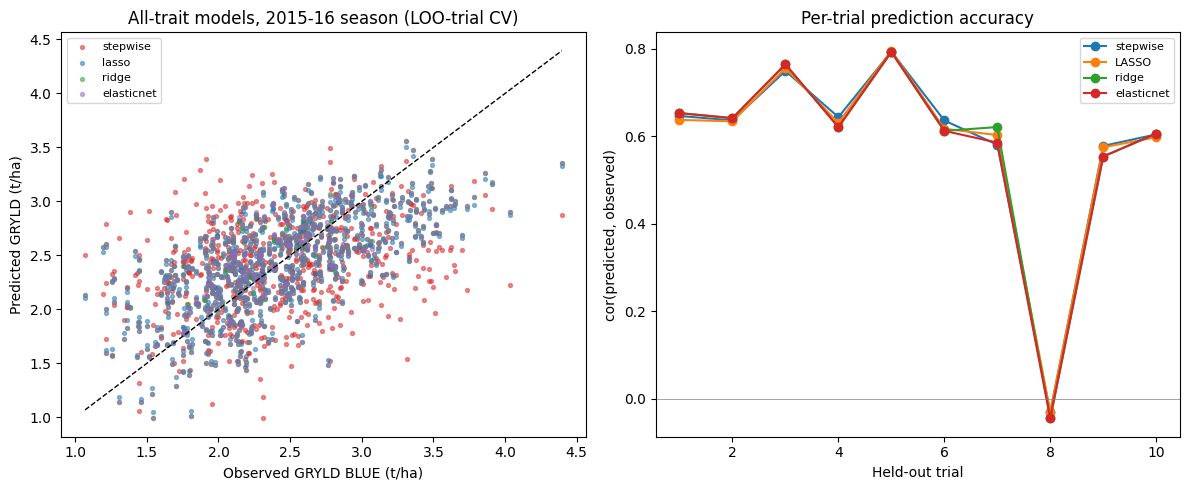

,trial,stepwise,LASSO,ridge,elasticnet
mean,5.5,0.584,0.582,0.582,0.578


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pred = pd.read_csv("/content/predicted_observed_2016.csv")
per_trial = pd.read_csv("/content/per_trial_accuracy_2016.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"predicted_stepwise": "tab:red", "predicted_lasso": "tab:blue",
          "predicted_ridge": "tab:green", "predicted_elasticnet": "tab:purple"}
for col, c in colors.items():
    axes[0].scatter(pred["observed"], pred[col], s=8, alpha=0.5, label=col.replace("predicted_", ""), color=c)
lims = [pred["observed"].min(), pred["observed"].max()]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("Observed GRYLD BLUE (t/ha)"); axes[0].set_ylabel("Predicted GRYLD (t/ha)")
axes[0].set_title("All-trait models, 2015-16 season (LOO-trial CV)")
axes[0].legend(fontsize=8)

for col in ["stepwise", "LASSO", "ridge", "elasticnet"]:
    axes[1].plot(per_trial["trial"], per_trial[col], "o-", label=col)
axes[1].set_xlabel("Held-out trial"); axes[1].set_ylabel("cor(predicted, observed)")
axes[1].set_title("Per-trial prediction accuracy")
axes[1].axhline(0, color="gray", lw=0.5); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("/content/accuracy_2016.png", dpi=120); plt.show()

per_trial.describe().loc[["mean"]].round(3)


### Interpretation, differences from the paper, validation record / 考察と限界

**Expected result (paper Table 2, 2015–16):** All-Traits prediction accuracy r = 0.58 for stepwise, LASSO, ridge, and ElasticNet (R² 0.43–0.46). This notebook should reproduce r ≈ 0.55–0.60; small differences are expected because (a) the authors' exact caret tuning outcome is version-dependent, (b) `lmer` optimizer versions differ, and (c) the paper's BLUE file was produced by the authors' commented-out export path. The **stepwise variable selection** and the **trial-level CV scheme** are the authors' own, run verbatim.

**What is demonstrated:** one season (2015–16) of the paper's multivariate secondary-trait yield-prediction pipeline end to end. **What is not:** the other four seasons, heritability estimation, univariate models, correlation profiles, and the top-10% selection analysis (Supplement S12); one good season does not verify the published dataset-level accuracies.

**Validation record:** executed top-to-bottom on a fresh Colab CPU runtime; the CLI-emitted `*_output.ipynb` and session log are archived with the run. Data provenance: Dryad version 140447 file 1020255 (size/SHA-256 verified in-cell). Code provenance: Zenodo record 5512861 (MIT), MD5-verified before embedding; the two 2016-season R sections are quoted above with edits marked.

**日本語:** 論文Table 2の2015–16年（All Traits, r=0.58）と比較してください。バージョン差により小さな差は想定内です。本ノートブックは1季節の部分再現であり、他季節・遺伝率・単変量解析は含みません。

**References**
- Juliana P. et al. (2021) Front. Plant Sci. 12:633651, doi:10.3389/fpls.2021.633651 (PMC8502926).
- Author R code: Zenodo 5512861 (MIT), `BLUE_allYears.R`, `Multivar_yieldpred_alltrait_allYear.R`.
- Data: Dryad doi:10.5061/dryad.vdncjsxrz, CC0; `2016_Data.csv` (file 1020255), `README.txt` (file 1020259).
